In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.4 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import zipfile
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt

import ultralytics
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ZIP_PATH="/content/drive/MyDrive/Smart_Warehouse_Inventory_Project.zip"

EXTRACT_PATH="/content"

with zipfile.ZipFile(ZIP_PATH,"r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Project Extracted Successfully")

Project Extracted Successfully


In [5]:
PROJECT_ROOT=Path("/content/Smart_Warehouse_Inventory_Project")

DATASET_PATH=PROJECT_ROOT/"dataset"

DATA_YAML=DATASET_PATH/"data.yaml"

MODEL_PATH=Path("/content/drive/MyDrive/YOLO_Training_imgsz640/warehouse_inventory_100epochs/weights/best_100epochs.pt")

RESULTS_FOLDER=Path("/content/drive/MyDrive/YOLO_Training_imgsz640/warehouse_inventory_100epochs")
print(PROJECT_ROOT.exists())
print(DATASET_PATH.exists())
print(DATA_YAML.exists())
print(MODEL_PATH.exists())
print(RESULTS_FOLDER.exists())

True
True
True
True
True


In [6]:
# Load MOdel
model=YOLO(MODEL_PATH)

print("Model Loaded Successfully")

Model Loaded Successfully


In [7]:
# Validation
metrics=model.val(
    data=str(DATA_YAML)
)

print("Validation Completed Successfully")

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1892.4±920.6 MB/s, size: 372.0 KB)
val: Scanning /content/Smart_Warehouse_Inventory_Project/dataset/labels/val... 1125 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1125/1125 820.3it/s 1.4s
val: New cache created: /content/Smart_Warehouse_Inventory_Project/dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 5.2s/it 6:12
                   all       1125      13873      0.751       0.71      0.763      0.682
                   box       1038       1038      0.769      0.778      0.836      0.762
                 crate        218        218      0.727      0.578      0.664      0.538
                barrel        206        206      0.647      0.535      0.621        0.5
              

In [8]:
# Model Evaluation

print(f"mAP@0.5        : {metrics.box.map50:.4f}")

print(f"mAP@0.5:0.95   : {metrics.box.map:.4f}")

print(f"Precision      : {metrics.box.mp:.4f}")

print(f"Recall         : {metrics.box.mr:.4f}")

mAP@0.5        : 0.7630
mAP@0.5:0.95   : 0.6819
Precision      : 0.7507
Recall         : 0.7097


In [12]:
# Read Training Results

results_csv=RESULTS_FOLDER/"results.csv"

results_df=pd.read_csv(results_csv)

results_df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,144.479,1.73228,4.06401,1.64964,0.36126,0.10932,0.05901,0.04106,1.47438,3.40676,1.44312,0.000115,0.000115,0.000115
1,2,281.055,1.24628,2.98513,1.31810,0.56613,0.16314,0.13262,0.10052,1.15470,2.70746,1.20492,0.000227,0.000227,0.000227
2,3,417.080,1.05987,2.46243,1.18986,0.47846,0.20997,0.19353,0.14504,1.00588,2.32534,1.10789,0.000338,0.000338,0.000338
3,4,551.033,0.95823,2.16322,1.12044,0.35310,0.30093,0.27085,0.20686,0.88998,1.98521,1.03608,0.000335,0.000335,0.000335
4,5,687.924,0.90614,1.97467,1.08770,0.49526,0.32872,0.32031,0.25541,0.82204,1.78542,0.99910,0.000331,0.000331,0.000331


In [13]:
# Display last epoch
results_df.tail(1)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
99,100,13762.6,0.41182,0.56667,0.86779,0.74934,0.70955,0.76305,0.68134,0.37152,0.54028,0.777,0.000007,0.000007,0.000007


In [14]:
# Best epoch
best_epoch=results_df["metrics/mAP50(B)"].idxmax()

print("Best Epoch :",best_epoch)

print()

print(results_df.loc[best_epoch])

Best Epoch : 98

epoch                      99.00000
time                    13626.00000
train/box_loss              0.41131
train/cls_loss              0.56308
train/dfl_loss              0.86646
metrics/precision(B)        0.75614
metrics/recall(B)           0.70767
metrics/mAP50(B)            0.76351
metrics/mAP50-95(B)         0.68118
val/box_loss                0.37277
val/cls_loss                0.54132
val/dfl_loss                0.77742
lr/pg0                      0.00001
lr/pg1                      0.00001
lr/pg2                      0.00001
Name: 98, dtype: float64


In [15]:
from pathlib import Path

for file in sorted(RESULTS_FOLDER.iterdir()):
    print(file.name)



BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch26190.jpg
train_batch26191.jpg
train_batch26192.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


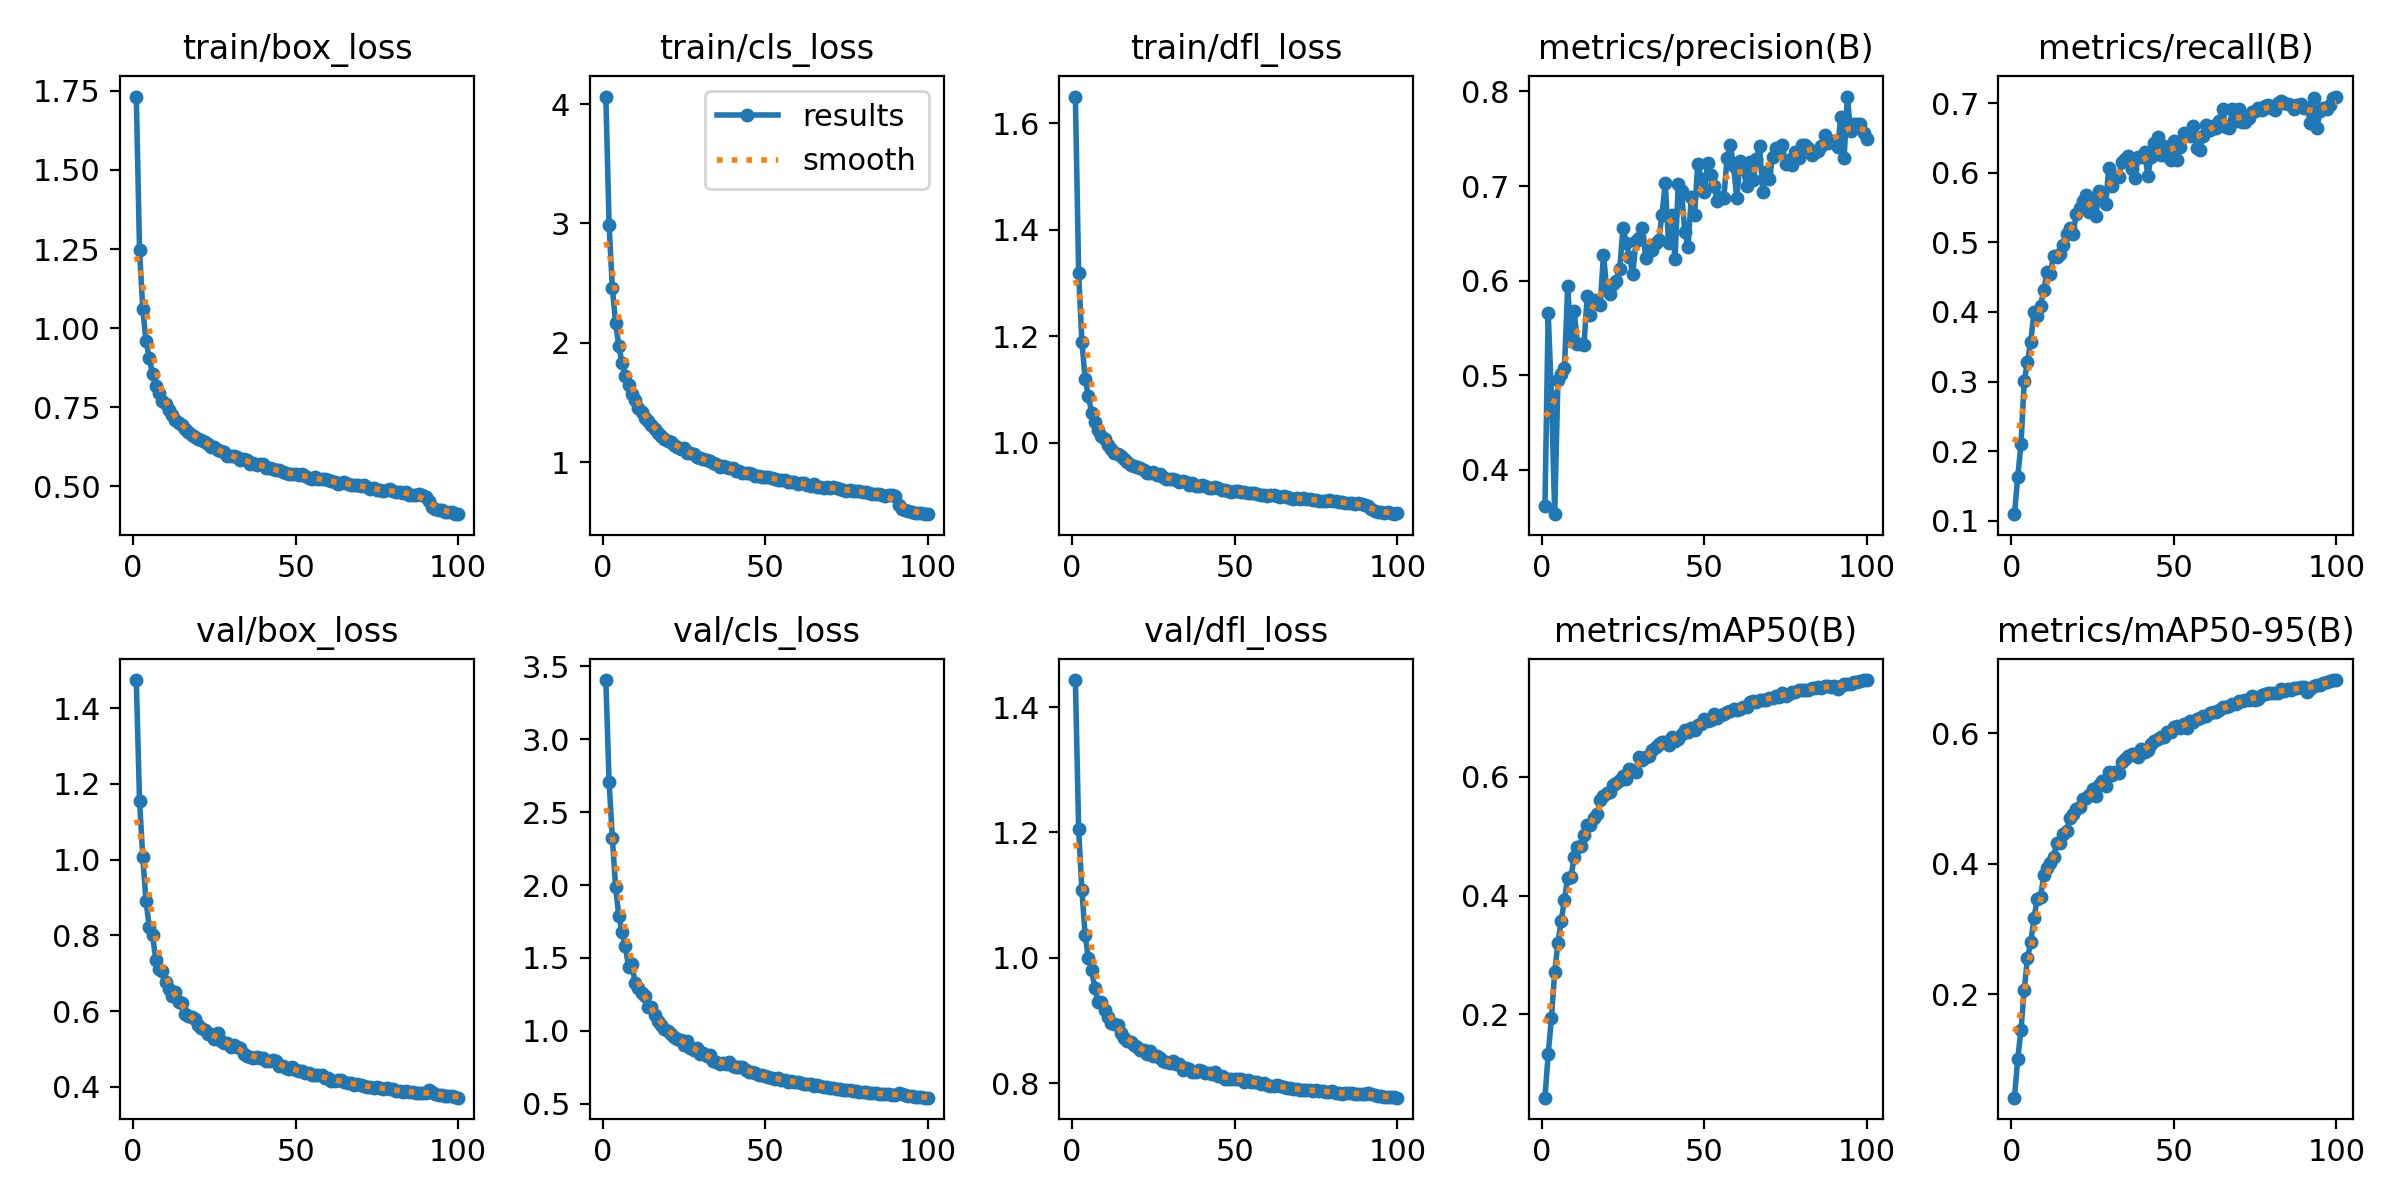

In [16]:
# Display Training Curves
from IPython.display import Image

Image(filename=str(RESULTS_FOLDER/"results.png"))

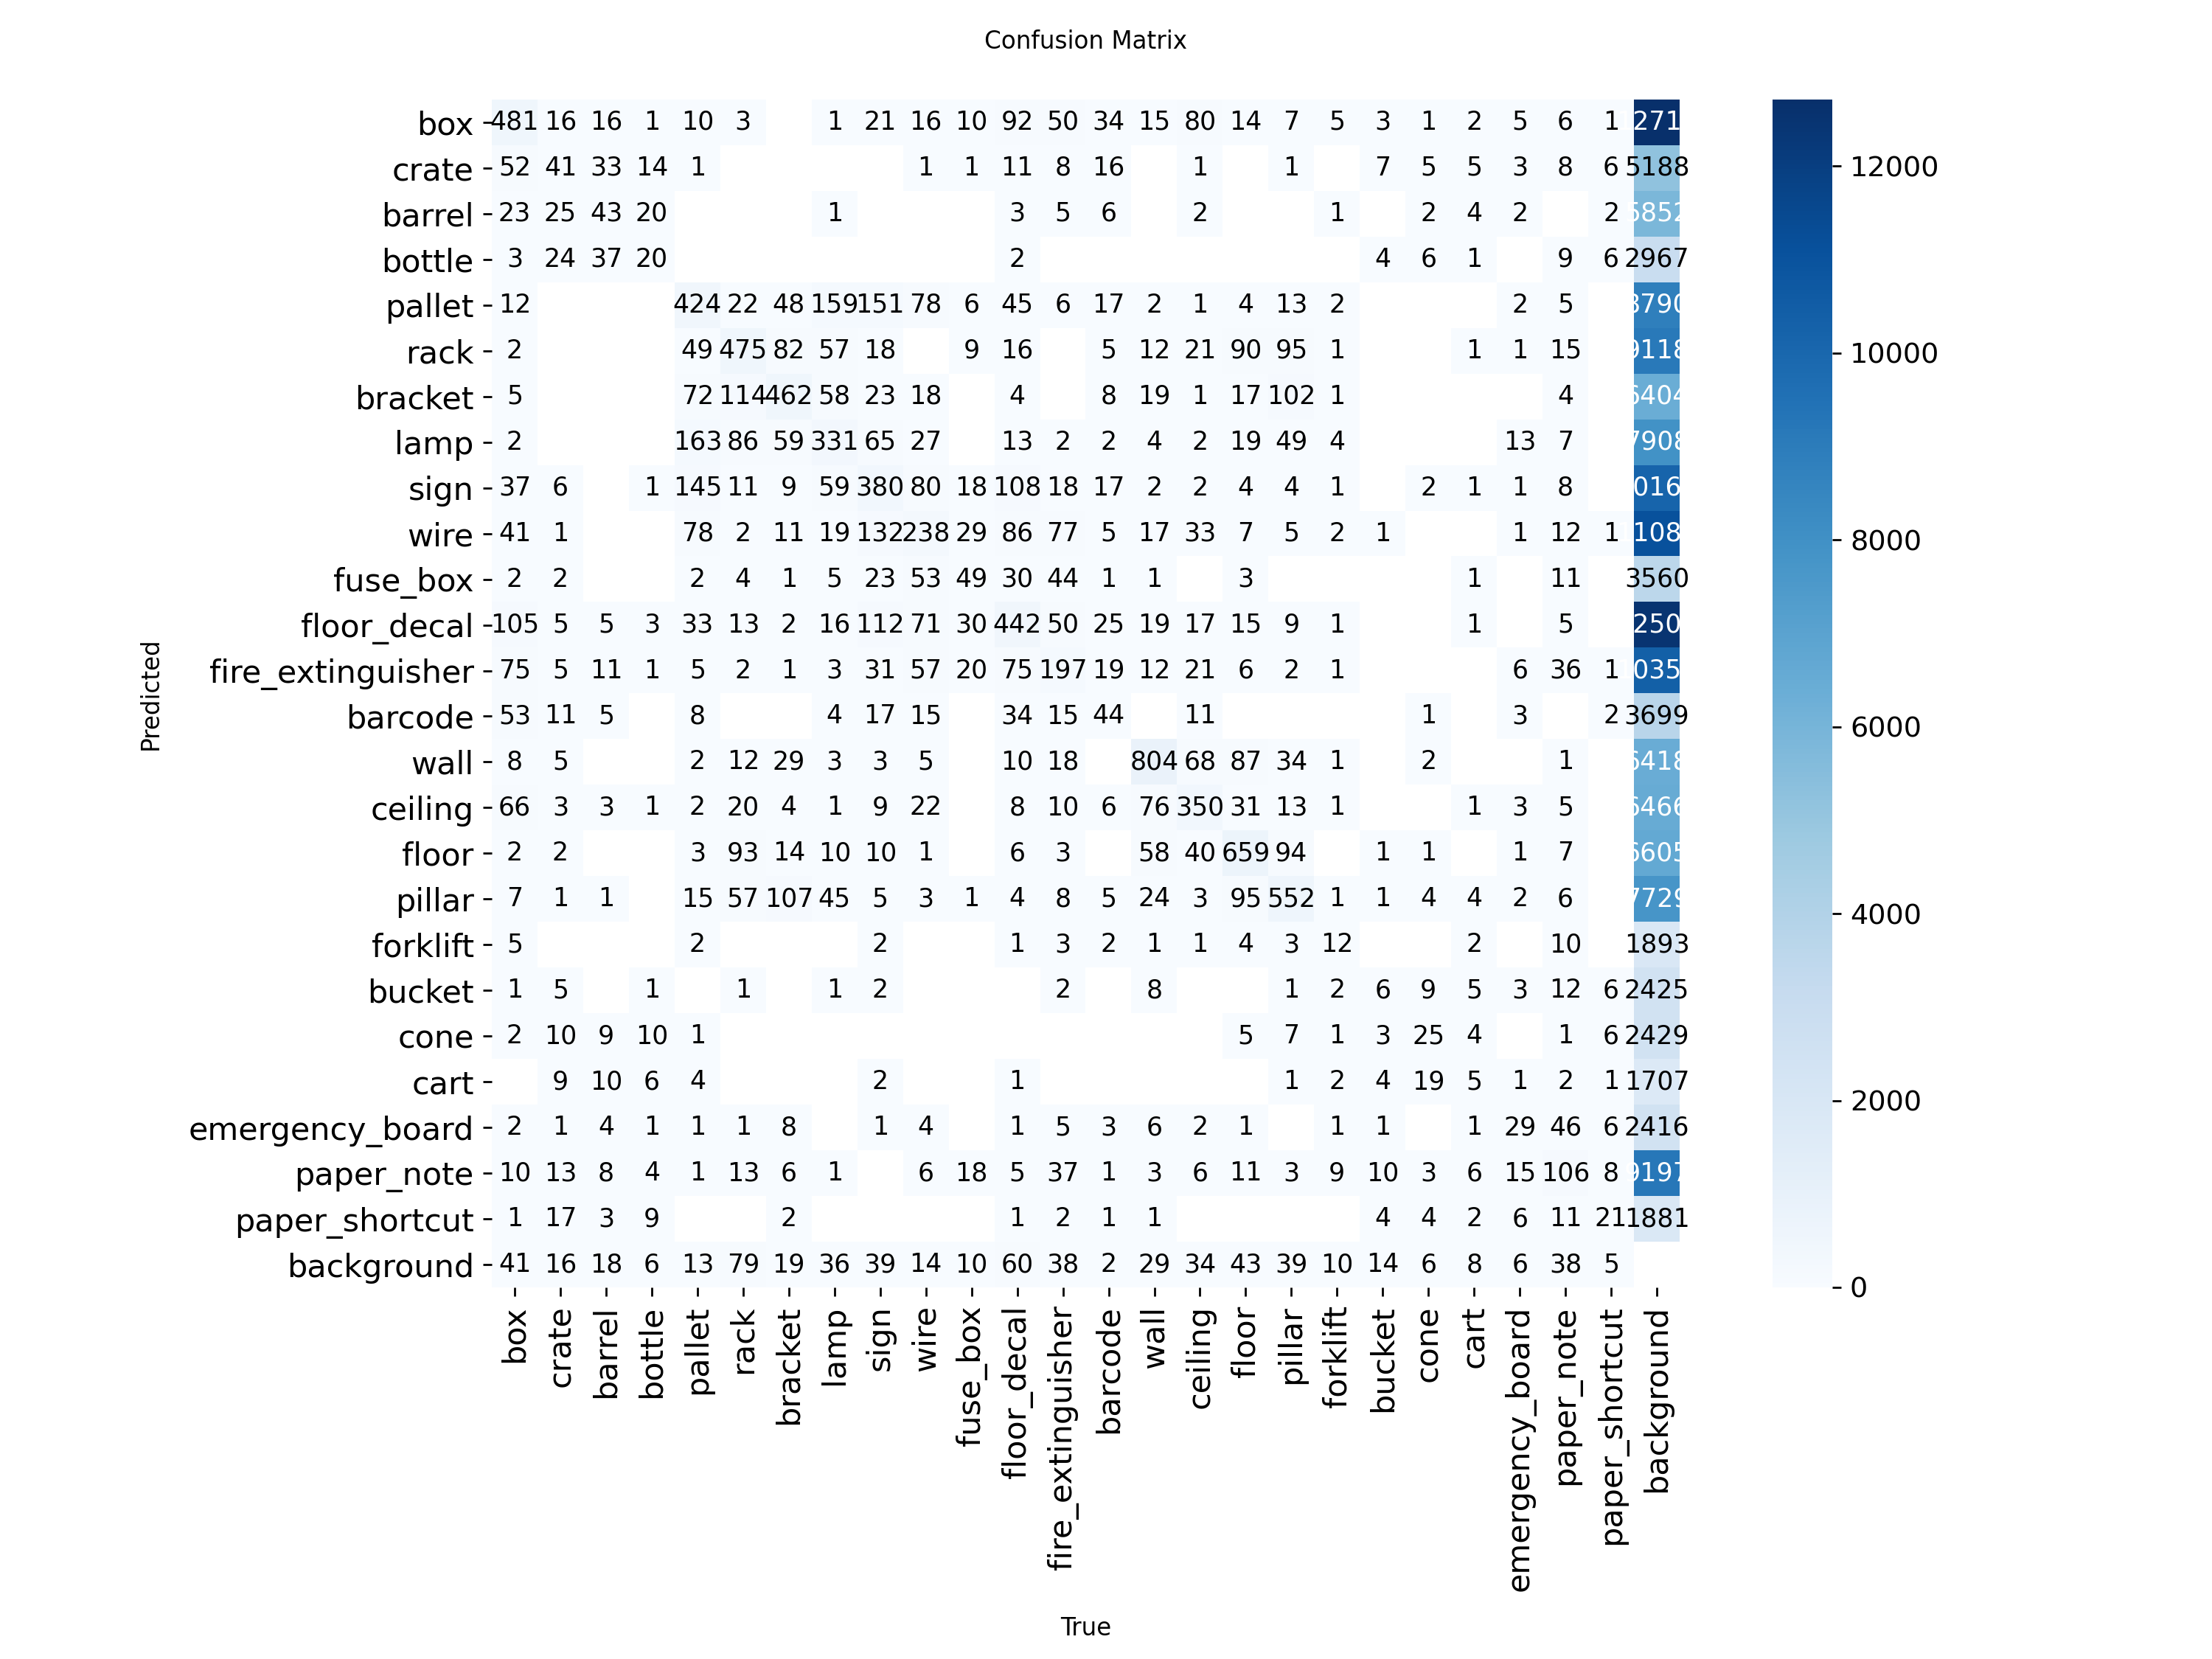

In [17]:
# Confusion Matrix

Image(filename=str(RESULTS_FOLDER/"confusion_matrix.png"))



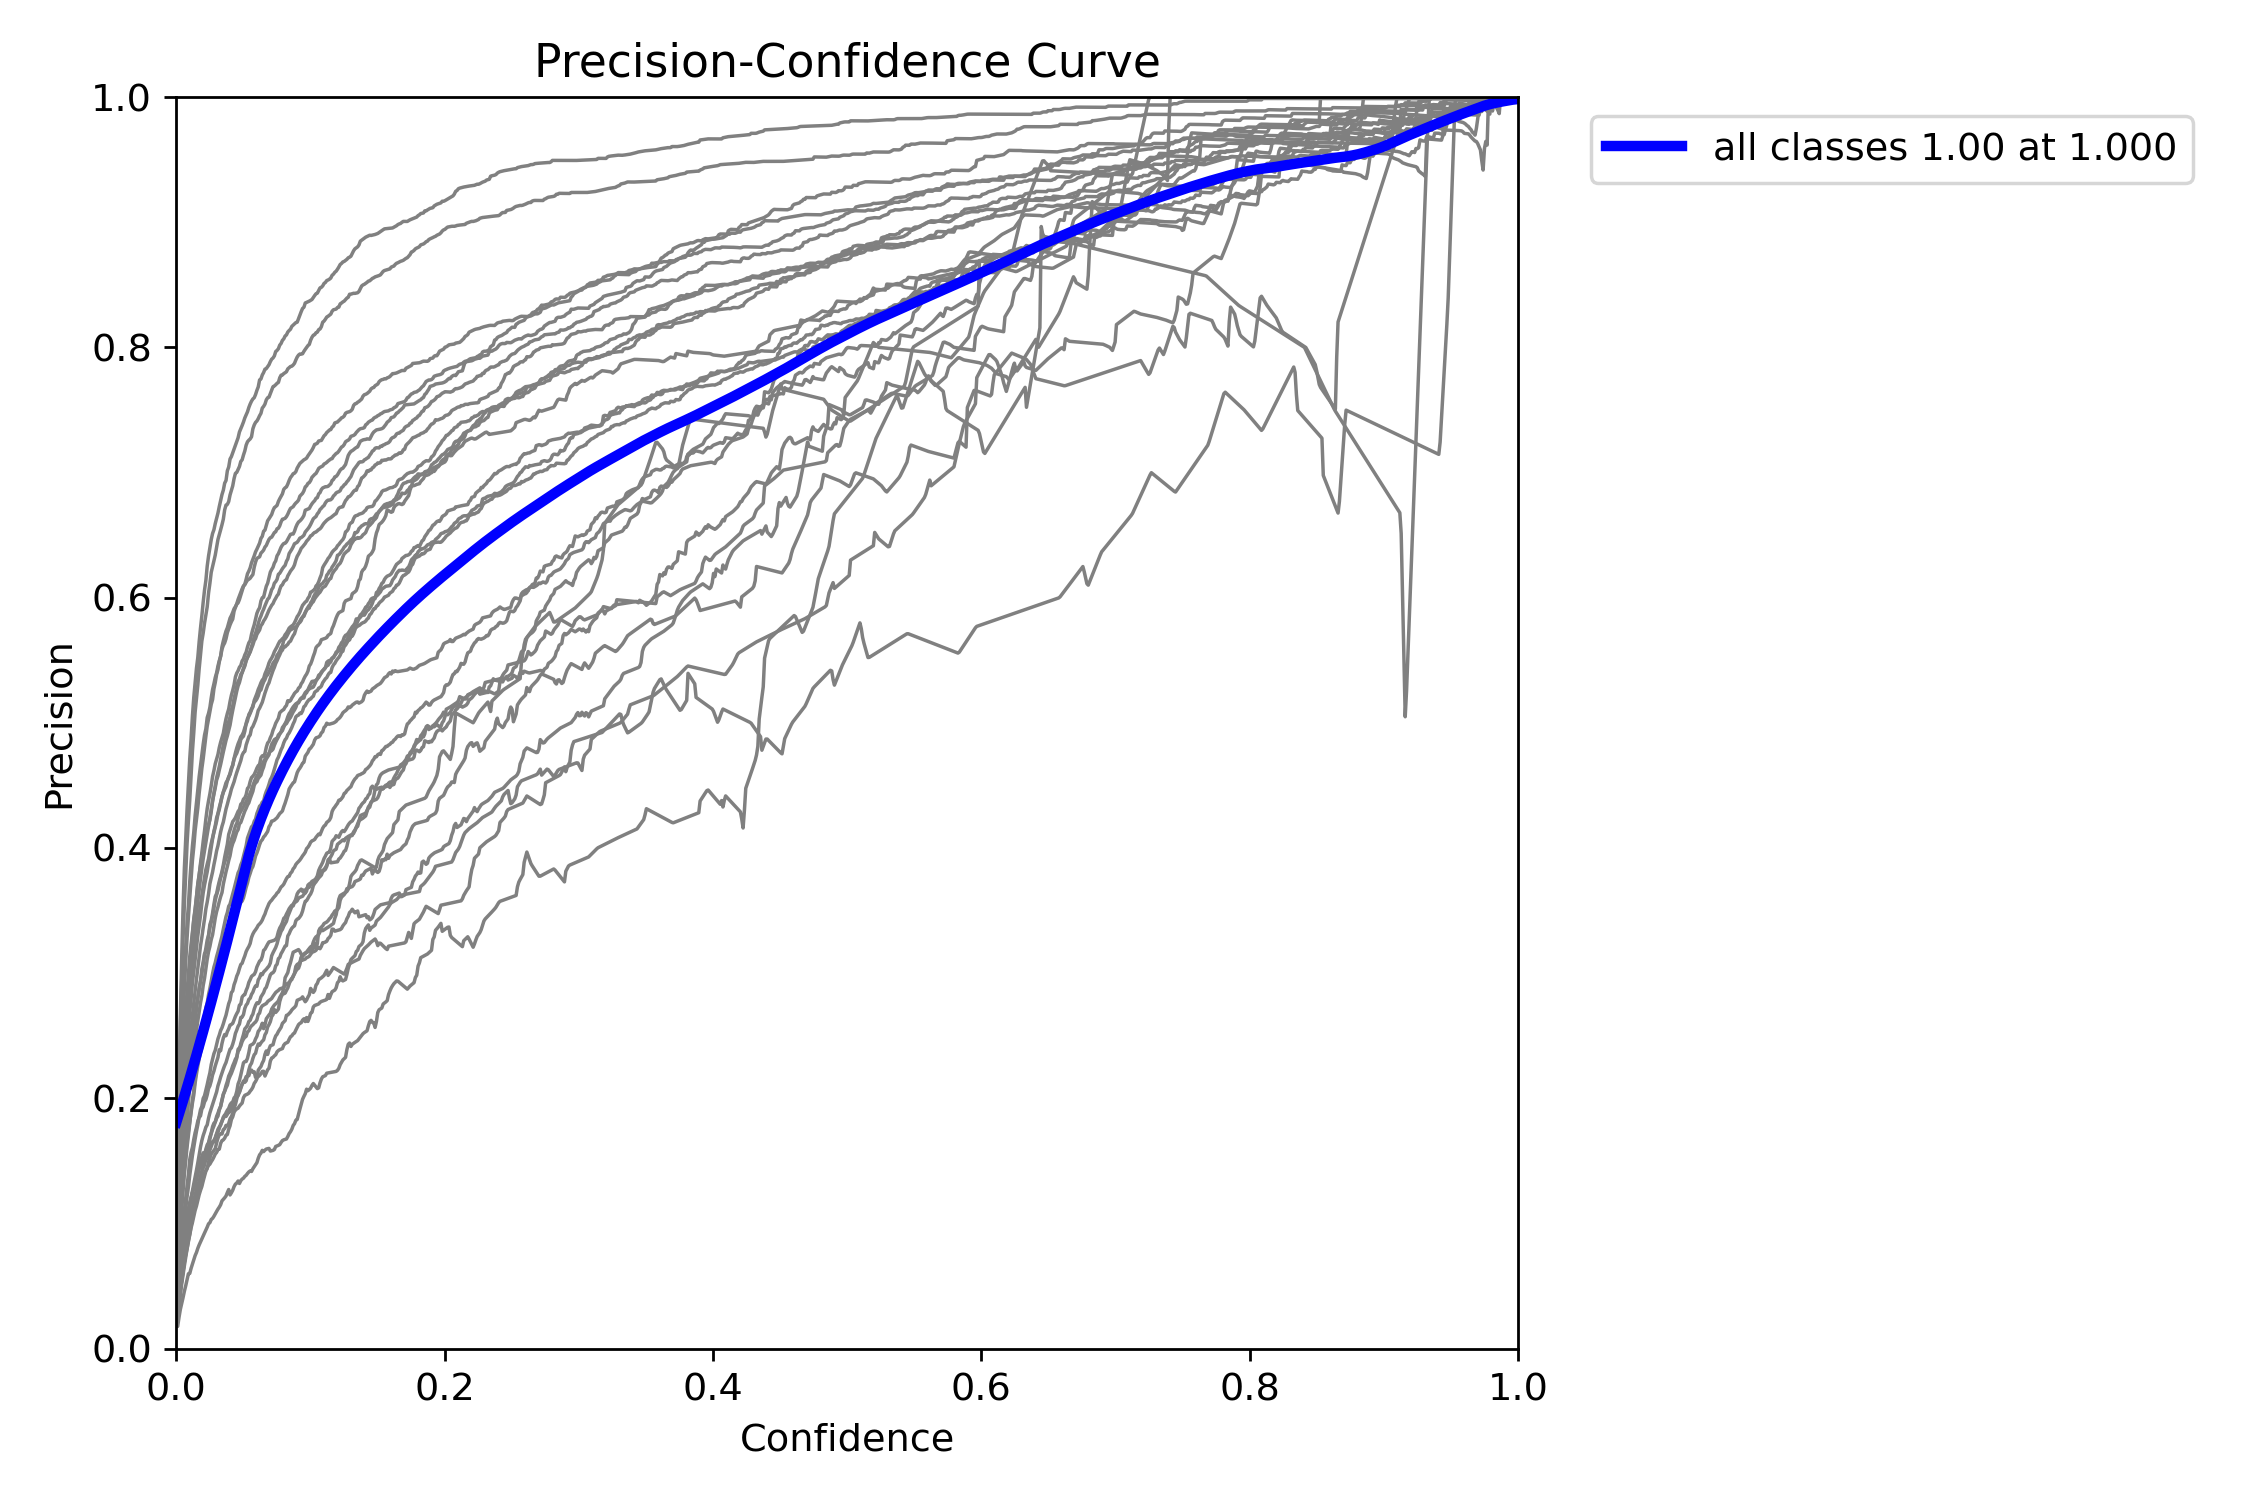

In [18]:
# Precision Curve
Image(filename=str(RESULTS_FOLDER/"BoxP_curve.png"))

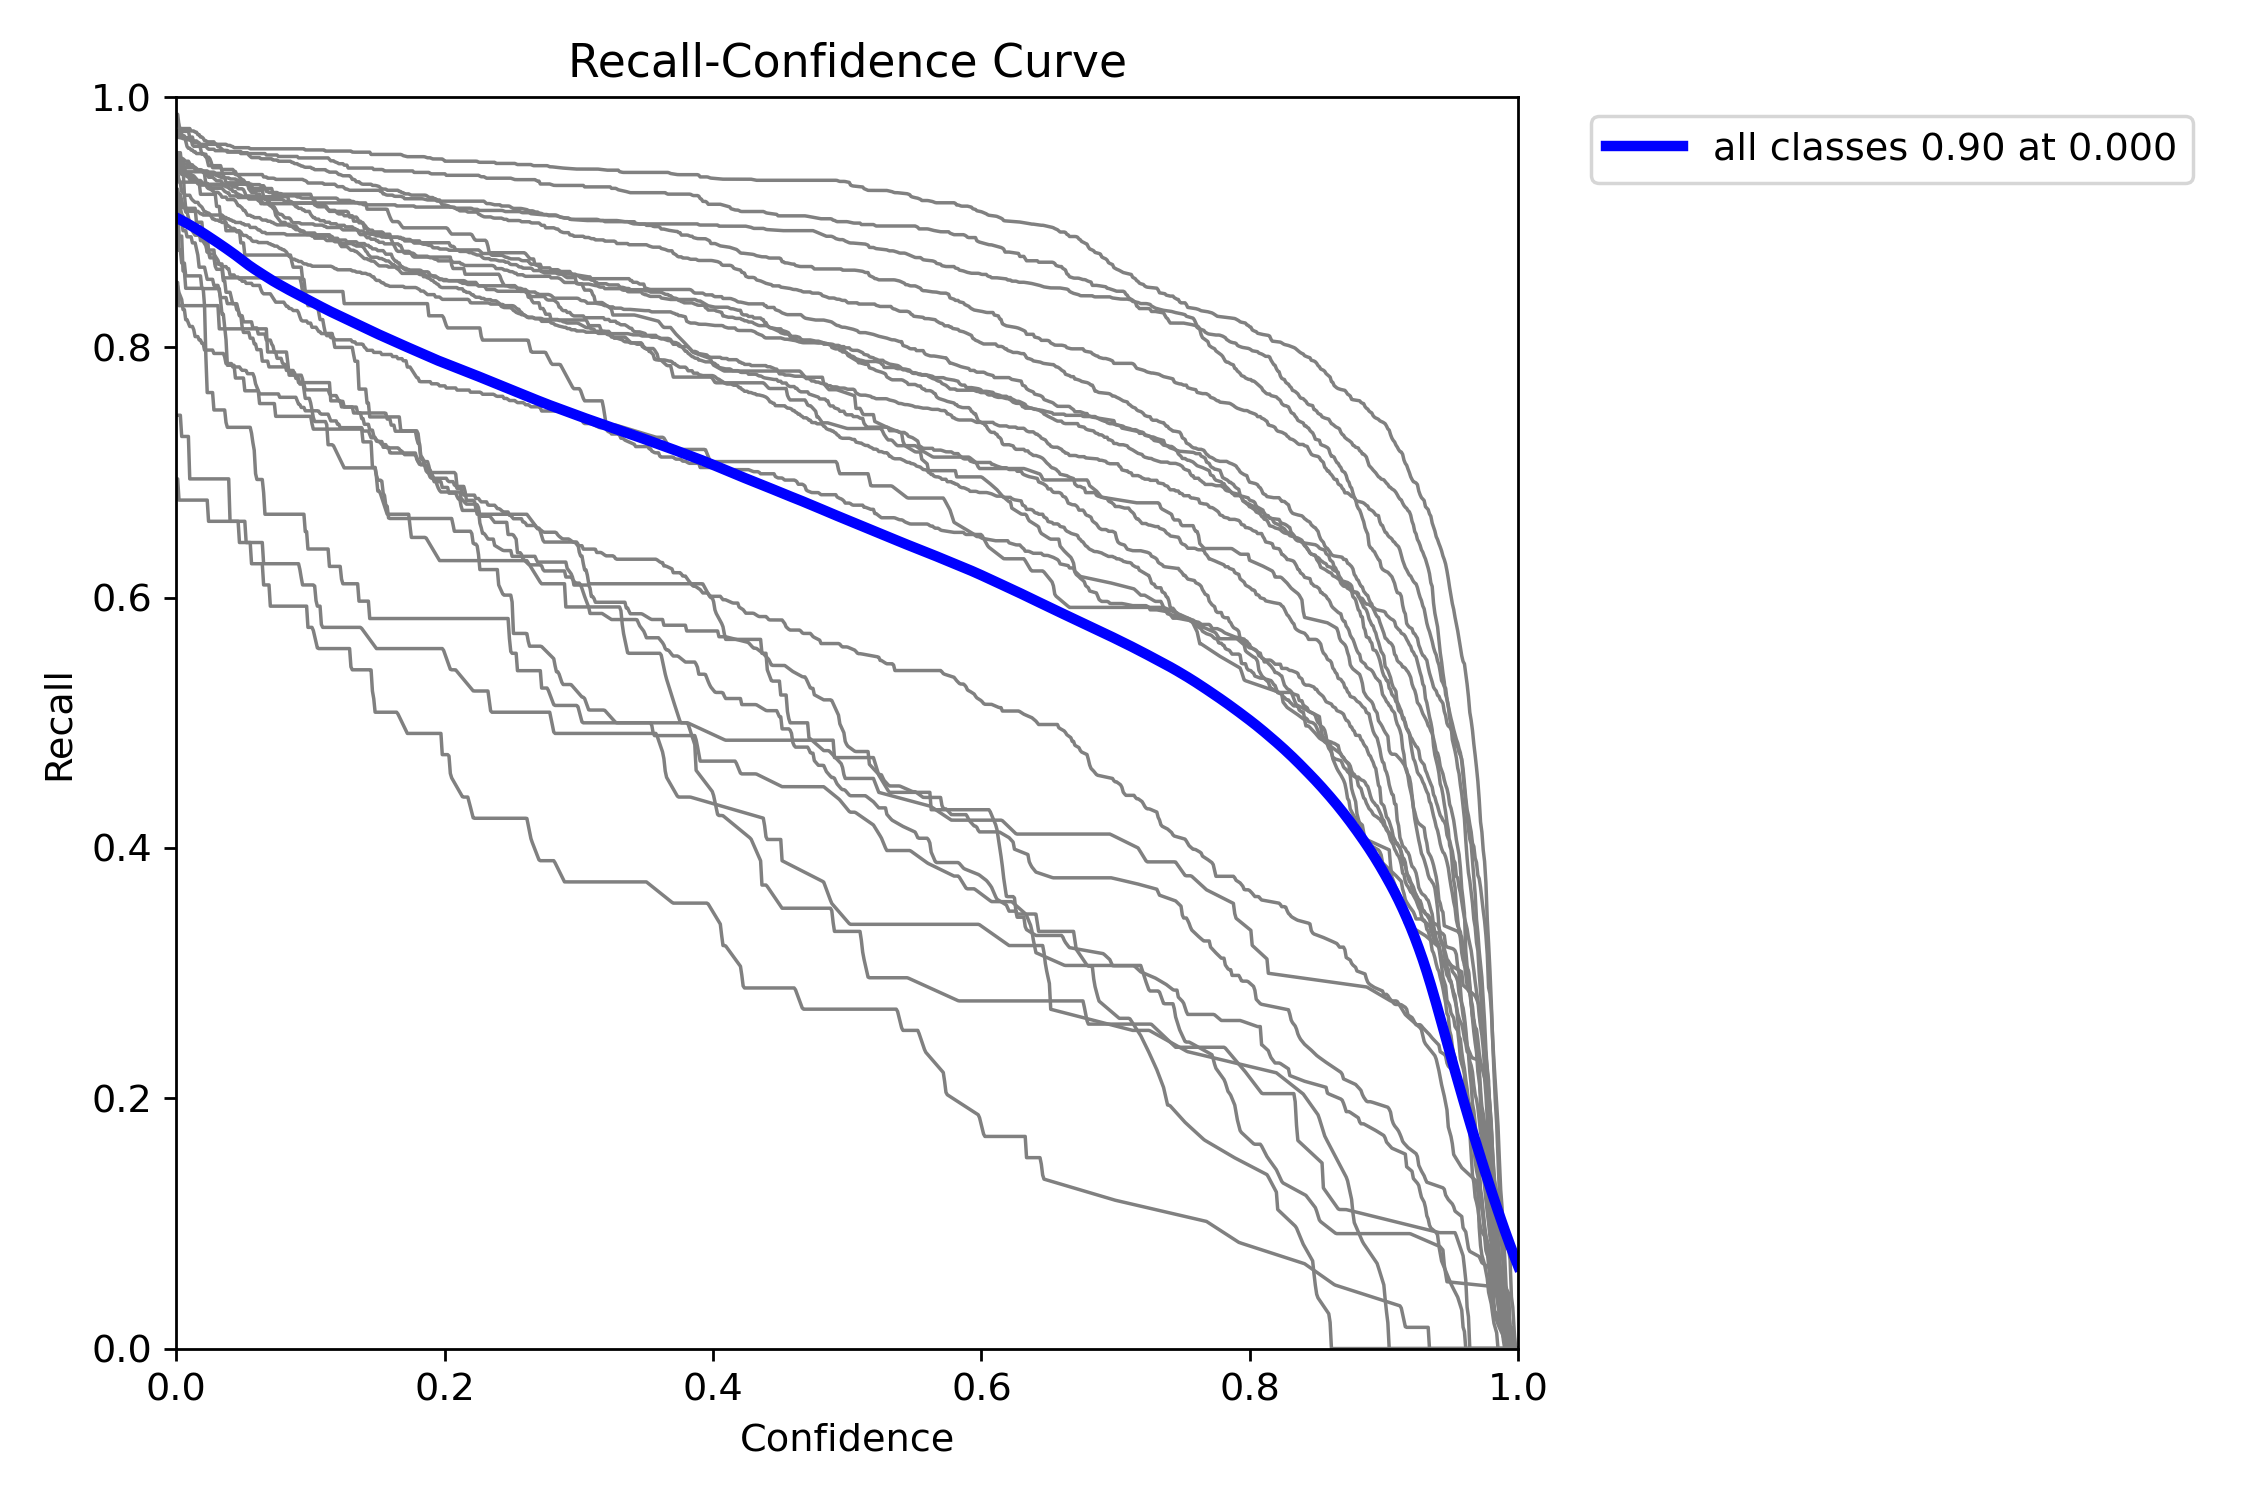

In [19]:
# Recall Curve
Image(filename=str(RESULTS_FOLDER/"BoxR_curve.png"))

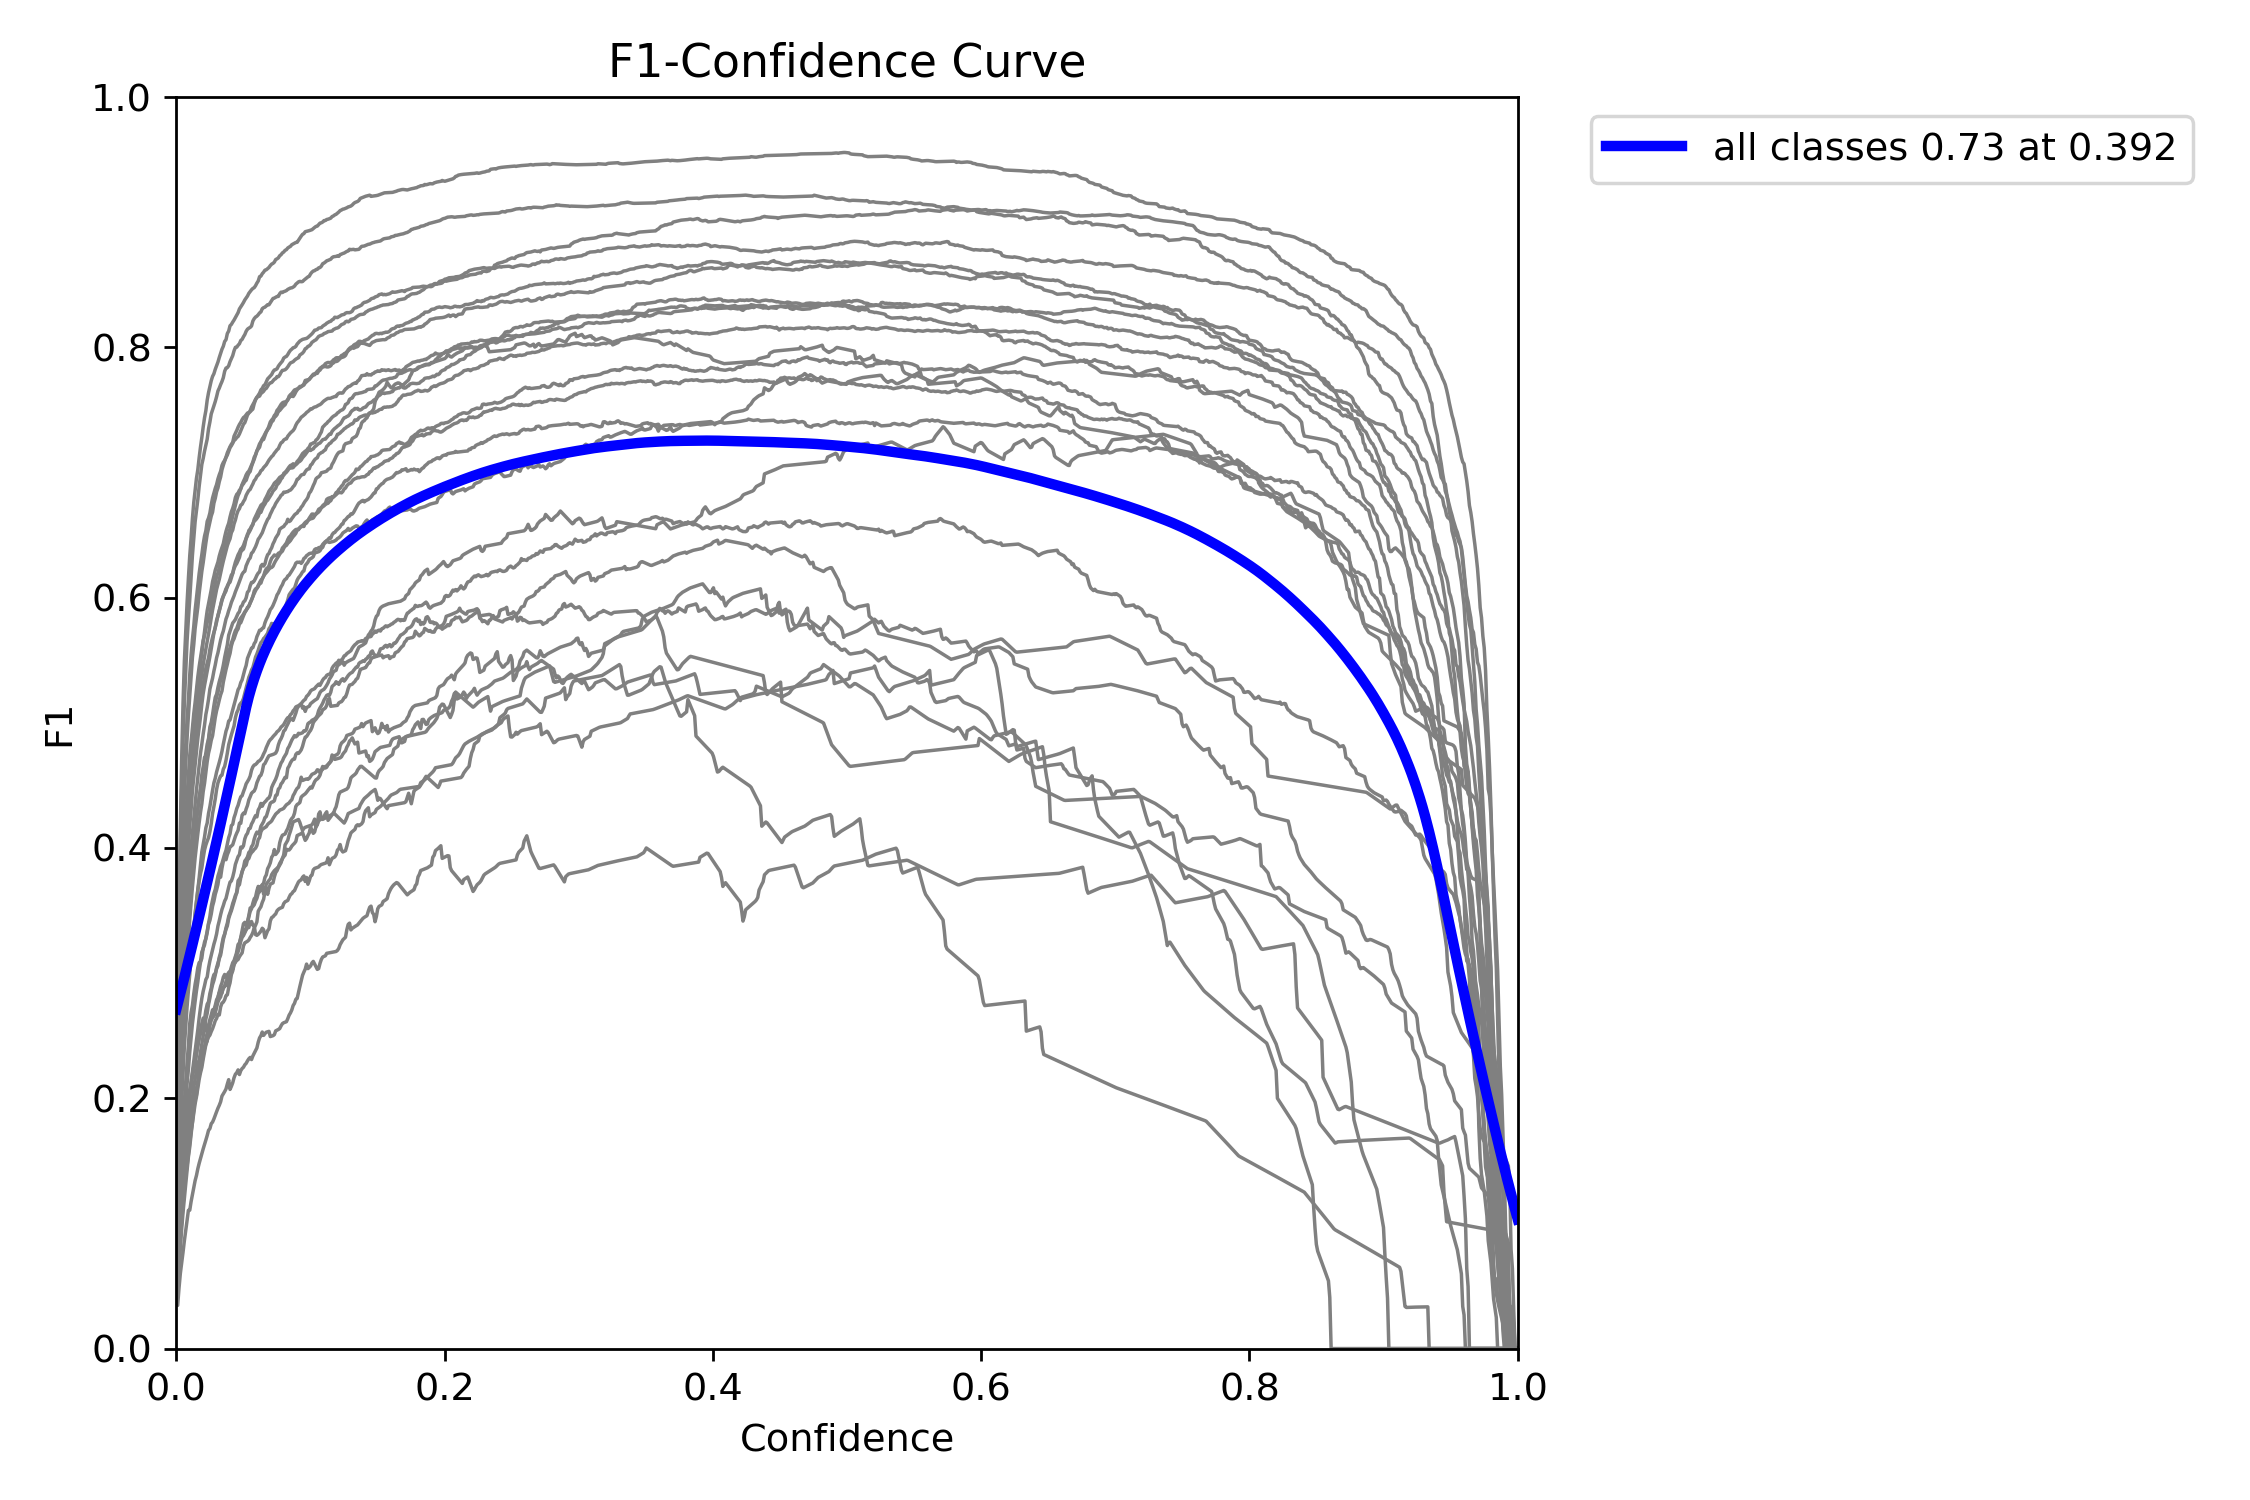

In [20]:
# F1 Curve
Image(filename=str(RESULTS_FOLDER/"BoxF1_curve.png"))

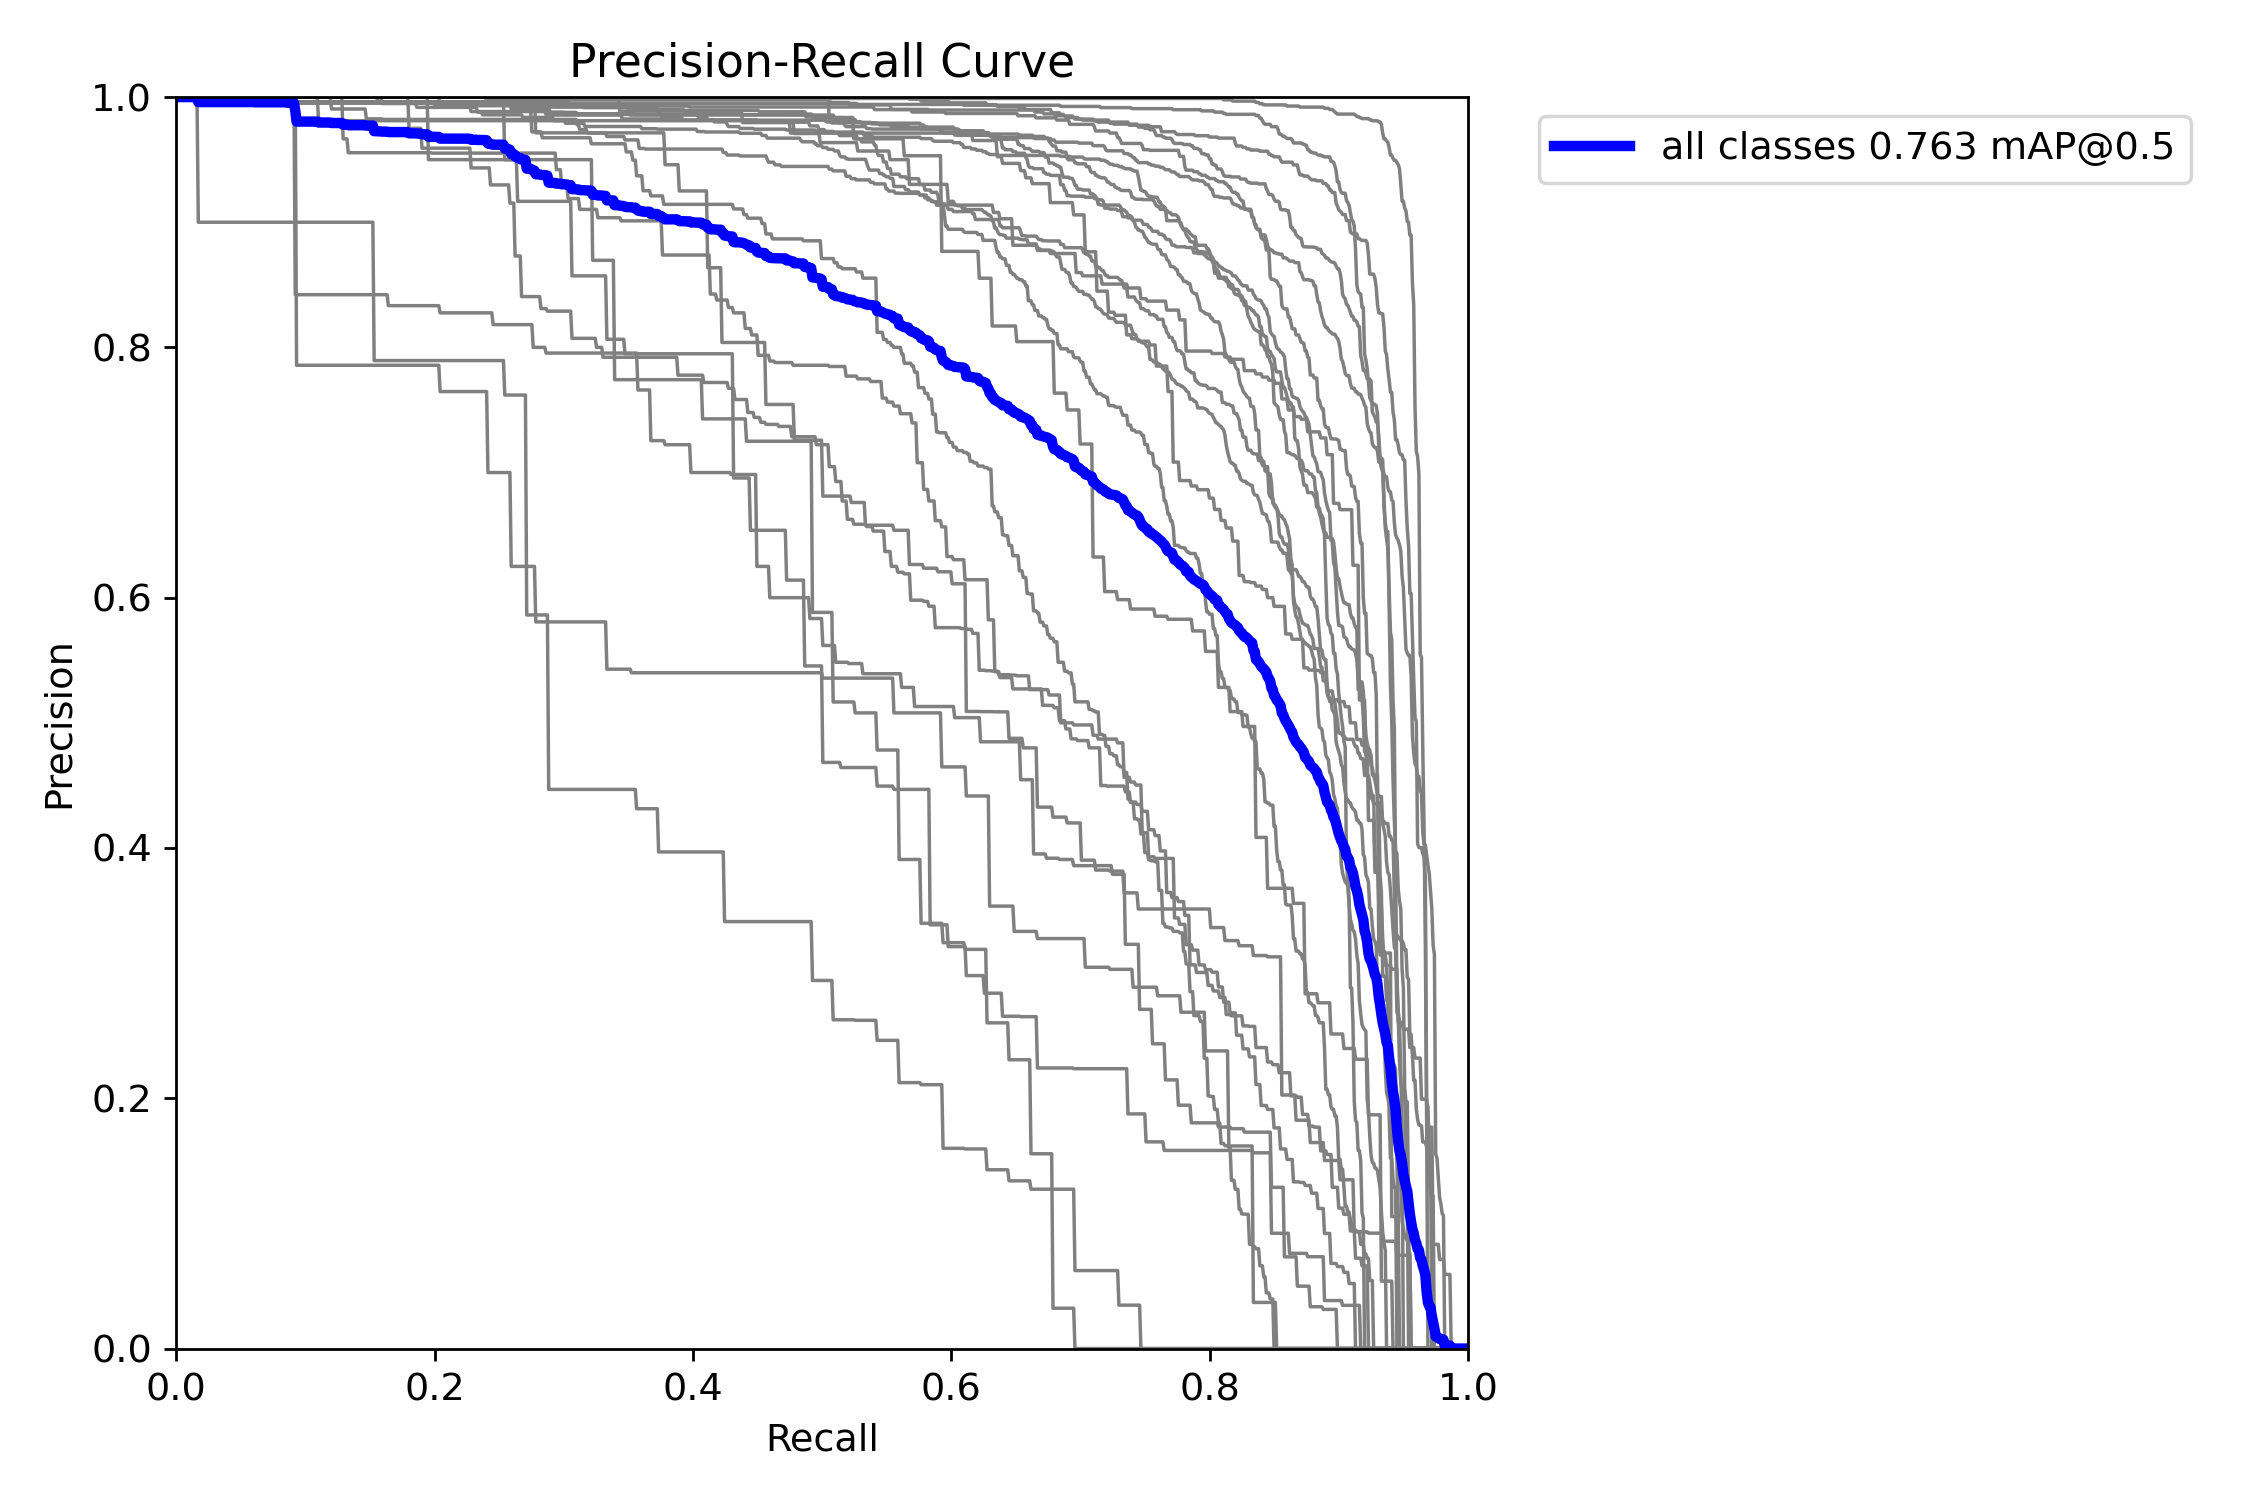

In [21]:
# PR Curve
Image(filename=str(RESULTS_FOLDER/"BoxPR_curve.png"))


In [22]:
# To display all at once
from IPython.display import Image, display

display(Image(filename=str(RESULTS_FOLDER/"confusion_matrix.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxP_curve.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxR_curve.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxF1_curve.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxPR_curve.png")))

Output hidden; open in https://colab.research.google.com to view.

In [23]:

# COMPLETE TRAINING HISTORY


pd.set_option("display.max_columns", None)

results_df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,144.479,1.73228,4.06401,1.64964,0.36126,0.10932,0.05901,0.04106,1.47438,3.40676,1.44312,0.000115,0.000115,0.000115
1,2,281.055,1.24628,2.98513,1.31810,0.56613,0.16314,0.13262,0.10052,1.15470,2.70746,1.20492,0.000227,0.000227,0.000227
2,3,417.080,1.05987,2.46243,1.18986,0.47846,0.20997,0.19353,0.14504,1.00588,2.32534,1.10789,0.000338,0.000338,0.000338
3,4,551.033,0.95823,2.16322,1.12044,0.35310,0.30093,0.27085,0.20686,0.88998,1.98521,1.03608,0.000335,0.000335,0.000335
4,5,687.924,0.90614,1.97467,1.08770,0.49526,0.32872,0.32031,0.25541,0.82204,1.78542,0.99910,0.000331,0.000331,0.000331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,13215.100,0.41793,0.57541,0.86820,0.76560,0.69317,0.75946,0.67729,0.37577,0.54756,0.77877,0.000021,0.000021,0.000021
96,97,13352.500,0.41666,0.57461,0.87061,0.76605,0.69178,0.76095,0.67837,0.37497,0.54648,0.77806,0.000017,0.000017,0.000017
97,98,13489.300,0.41771,0.57702,0.86859,0.76589,0.69775,0.76227,0.67920,0.37493,0.54437,0.77758,0.000014,0.000014,0.000014
98,99,13626.000,0.41131,0.56308,0.86646,0.75614,0.70767,0.76351,0.68118,0.37277,0.54132,0.77742,0.000010,0.000010,0.000010


In [24]:

# TRAINING SUMMARY


print("Total Epochs :", len(results_df))

print("Best mAP@0.5 :", results_df["metrics/mAP50(B)"].max())

print("Best Precision :", results_df["metrics/precision(B)"].max())

print("Best Recall :", results_df["metrics/recall(B)"].max())



Total Epochs : 100
Best mAP@0.5 : 0.76351
Best Precision : 0.79466
Best Recall : 0.70955


In [25]:

# SAVE EVALUATION REPORT


report_path = RESULTS_FOLDER / "evaluation_summary_100epochs.txt"

with open(report_path, "w") as file:

    file.write("YOLO MODEL EVALUATION\n")
    file.write("="*50 + "\n\n")

    file.write(f"Best mAP@0.5 : {results_df['metrics/mAP50(B)'].max():.4f}\n")

    file.write(f"Best Precision : {results_df['metrics/precision(B)'].max():.4f}\n")

    file.write(f"Best Recall : {results_df['metrics/recall(B)'].max():.4f}\n")

print("Evaluation report saved successfully.")

Evaluation report saved successfully.


In [26]:
# GENERATED FILES


for file in sorted(RESULTS_FOLDER.iterdir()):

    print(file.name)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
evaluation_summary_100epochs.txt
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch26190.jpg
train_batch26191.jpg
train_batch26192.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


In [ ]:
!pip install ImageHash
from PIL import Image
import imagehash
from pathlib import Path

val_dir = DATASET_PATH / "images" / "val"

hashes = {}

duplicates = []

for img_path in val_dir.glob("*"):
    h = imagehash.average_hash(Image.open(img_path))

    if h in hashes:
        duplicates.append((hashes[h], img_path.name))
    else:
        hashes[h] = img_path.name

print("Duplicate pairs:", len(duplicates))

duplicates[:20]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.1 MB/s eta 0:00:00
Duplicate pairs: 403


[('warehouse_001033.png', 'warehouse_000964.png'),
 ('warehouse_002499.png', 'warehouse_002495.png'),
 ('warehouse_012526.png', 'warehouse_012539.png'),
 ('warehouse_001033.png', 'warehouse_000957.png'),
 ('warehouse_013074.png', 'warehouse_013075.png'),
 ('warehouse_012526.png', 'warehouse_012547.png'),
 ('warehouse_000302.png', 'warehouse_000307.png'),
 ('warehouse_011980.png', 'warehouse_011983.png'),
 ('warehouse_010626.png', 'warehouse_010627.png'),
 ('warehouse_012526.png', 'warehouse_012523.png'),
 ('warehouse_001266.png', 'warehouse_001269.png'),
 ('warehouse_001266.png', 'warehouse_001265.png'),
 ('warehouse_010175.png', 'warehouse_010183.png'),
 ('warehouse_011080.png', 'warehouse_011095.png'),
 ('warehouse_001033.png', 'warehouse_000992.png'),
 ('warehouse_001033.png', 'warehouse_001023.png'),
 ('warehouse_000365.png', 'warehouse_000363.png'),
 ('warehouse_002832.png', 'warehouse_002826.png'),
 ('warehouse_001033.png', 'warehouse_000936.png'),
 ('warehouse_000753.png', 'ware

In [ ]:
from pathlib import Path
import hashlib

val_dir = DATASET_PATH / "images" / "val"

hashes = {}
duplicates = []

for img_path in val_dir.glob("*"):
    with open(img_path, "rb") as f:
        md5 = hashlib.md5(f.read()).hexdigest()

    if md5 in hashes:
        duplicates.append((hashes[md5], img_path.name))
    else:
        hashes[md5] = img_path.name

print("Validation Images :", len(list(val_dir.glob("*"))))
print("Exact Duplicate Images :", len(duplicates))

if duplicates:
    print(duplicates[:20])
else:
    print("No exact duplicate images.")

Validation Images : 1125
Exact Duplicate Images : 0
No exact duplicate images.
